# 1. Setup

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
from datetime import datetime
import gc
import html
import json
import os
import threading
import time

# from google.colab import userdata
# import jax
import keras
from keras import layers
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, matthews_corrcoef, precision_recall_fscore_support
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import tensorflow as tf

In [3]:
DATASET_PATH = './dataset'
TRAIN_CSV = os.path.join(DATASET_PATH, 'train.csv')
TEST_CSV = os.path.join(DATASET_PATH, 'test.csv')
RESULTS_DIR = './results'
HISTORIES_DIR = os.path.join(RESULTS_DIR, 'histories')
ARTIFACTS_DIR = './artifacts'
MODEL_SUMMARIES_DIR = os.path.join(ARTIFACTS_DIR, 'model_summaries')
MODELS_DIR = os.path.join(ARTIFACTS_DIR, 'models')
FIGURES_DIR = './figures'

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

TRAINING_SEEDS = [123, 231, 321]
CORRUPTION_SEED = 0
SPLIT_SEED = 1

CORRUPTIONS = ['swap', 'substitution', 'deletion', 'insertion']
CORRUPTION_LEVELS = [0, 5, 10, 15, 20]

STANDARDIZATION = 'lower_and_strip_punctuation'

WORD_MAX_TOKENS = 5000
WORD_SEQUENCE_LENGTH = 69
WORD_EMBEDDING_DIM = 32

CHAR_MAX_TOKENS = 200
CHAR_SEQUENCE_LENGTH = 443     
CHAR_EMBEDDING_DIM = 32

CONV_FILTERS = 128
KERNEL_SIZE = 5
DENSE_UNITS = 64

HIDDEN_ACTIVATION = "relu"
OUTPUT_ACTIVATION = "softmax"

DROPOUT_RATE = 0.2

NUM_CLASSES = 4

LEARNING_RATE = 1e-3
ALPHA = 0.01
DECAY_STEPS = 2820

EPOCHS = 50
PATIENCE = 5
PATIENCE_MIN_DELTA = 0.005
BATCH_SIZE = 64

MODEL_ORDER = ['word', 'char']

METRICS = {
    'accuracy': 'Accuracy',
    'f1_macro': 'Macro F1',
    'mcc': 'MCC',
    'log_loss': 'Log loss',
}

RELATIVE_METRICS = {
    'accuracy': 'Accuracy',
    'f1_macro': 'Macro F1',
    'log_loss': 'Log loss',
}

ABS_DEGRADATION_LABELS = {
    'accuracy': 'Accuracy drop',
    'f1_macro': 'Macro F1 drop',
    'mcc': 'MCC drop',
    'log_loss': 'Log-loss increase',
}

In [4]:
CONFIG = {
    'run_id': RUN_ID,

    'training_seeds': TRAINING_SEEDS,
    'corruption_seed': CORRUPTION_SEED,
    'split_seed': SPLIT_SEED,

    'corruption_levels': CORRUPTION_LEVELS,
    
    'standardization': STANDARDIZATION,

    'word_max_tokens': WORD_MAX_TOKENS,
    'word_sequence_length': WORD_SEQUENCE_LENGTH,
    'word_embedding_dim': WORD_EMBEDDING_DIM,

    'char_max_tokens': CHAR_MAX_TOKENS,
    'char_sequence_length': CHAR_SEQUENCE_LENGTH,
    'char_embedding_dim': CHAR_EMBEDDING_DIM,

    'conv_filters': CONV_FILTERS,
    'kernel_size': KERNEL_SIZE,
    'dense_units': DENSE_UNITS,

    'hidden_activation': HIDDEN_ACTIVATION,
    'output_activation': OUTPUT_ACTIVATION,

    'dropout_rate': DROPOUT_RATE,
    
    'num_classes': NUM_CLASSES,

    'learning_rate': LEARNING_RATE,
    'alpha': ALPHA,
    'decay_steps': DECAY_STEPS,

    'epochs': EPOCHS,
    'patience': PATIENCE,
    'batch_size': BATCH_SIZE,
}

In [5]:
config_path = os.path.join(
    ARTIFACTS_DIR,
    f'config_{RUN_ID}.json',
)

with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=4)

In [6]:
QWERTY_NEIGHBORS = {
    '`': ['1', 'q'],
    '~': ['!', 'Q'],
    '1': ['`', '2', 'q', 'w'],
    '!': ['~', '@', 'Q', 'W'],
    '2': ['1', '3', 'w', 'e'],
    '@': ['!', '#', 'W', 'E'],
    '3': ['2', '4', 'e', 'r'],
    '#': ['@', '$', 'E', 'R'],
    '4': ['3', '5', 'r', 't'],
    '$': ['#', '%', 'R', 'T'],
    '5': ['4', '6', 't', 'y'],
    '%': ['$', '^', 'T', 'Y'],
    '6': ['5', '7', 'y', 'u'],
    '^': ['%', '&', 'Y', 'U'],
    '7': ['6', '8', 'u', 'i'],
    '&': ['^', '*', 'U', 'I'],
    '8': ['7', '9', 'i', 'o'],
    '*': ['&', '(', 'I', 'O'],
    '9': ['8', '0', 'o', 'p'],
    '(': ['*', ')', 'O', 'P'],
    '0': ['9', '-', 'p', '['],
    ')': ['(', '_', 'P', '{'],
    '-': ['0', '=', '[', ']'],
    '_': [')', '+', '{', '}'],
    '=': ['-', ']', '['],
    '+': ['_', '}', '|'],

    'q': ['`', '1', 'w', 'a'],
    'Q': ['~', '!', 'W', 'A'],
    'w': ['1', '2', 'q', 'e', 'a', 's'],
    'W': ['!', '@', 'Q', 'E', 'A', 'S'],
    'e': ['2', '3', 'w', 'r', 's', 'd'],
    'E': ['@', '#', 'W', 'R', 'S', 'D'],
    'r': ['3', '4', 'e', 't', 'd', 'f'],
    'R': ['#', '$', 'E', 'T', 'D', 'F'],
    't': ['4', '5', 'r', 'y', 'f', 'g'],
    'T': ['$', '%', 'R', 'Y', 'F', 'G'],
    'y': ['5', '6', 't', 'u', 'g', 'h'],
    'Y': ['%', '^', 'T', 'U', 'G', 'H'],
    'u': ['6', '7', 'y', 'i', 'h', 'j'],
    'U': ['^', '&', 'Y', 'I', 'H', 'J'],
    'i': ['7', '8', 'u', 'o', 'j', 'k'],
    'I': ['&', '*', 'U', 'O', 'J', 'K'],
    'o': ['8', '9', 'i', 'p', 'k', 'l'],
    'O': ['*', '(', 'I', 'P', 'K', 'L'],
    'p': ['9', '0', 'o', '[', 'l', ';'],
    'P': ['(', ')', 'O', '{', 'L', ':'],
    '[': ['0', '-', 'p', ']', ';', "'"],
    '{': [')', '_', 'P', '}', ':', '"'],
    ']': ['-', '=', '[', '\\', "'"],
    '}': ['_', '+', '{', '|', '"'],
    '\\': ['=', ']'],
    '|': ['+', '}'],

    'a': ['q', 'w', 's', 'z'],
    'A': ['Q', 'W', 'S', 'Z'],
    's': ['w', 'e', 'a', 'd', 'z', 'x'],
    'S': ['W', 'E', 'A', 'D', 'Z', 'X'],
    'd': ['e', 'r', 's', 'f', 'x', 'c'],
    'D': ['E', 'R', 'S', 'F', 'X', 'C'],
    'f': ['r', 't', 'd', 'g', 'c', 'v'],
    'F': ['R', 'T', 'D', 'G', 'C', 'V'],
    'g': ['t', 'y', 'f', 'h', 'v', 'b'],
    'G': ['T', 'Y', 'F', 'H', 'V', 'B'],
    'h': ['y', 'u', 'g', 'j', 'b', 'n'],
    'H': ['Y', 'U', 'G', 'J', 'B', 'N'],
    'j': ['u', 'i', 'h', 'k', 'n', 'm'],
    'J': ['U', 'I', 'H', 'K', 'N', 'M'],
    'k': ['i', 'o', 'j', 'l', 'm', ','],
    'K': ['I', 'O', 'J', 'L', 'M', '<'],
    'l': ['o', 'p', 'k', ';', ',', '.'],
    'L': ['O', 'P', 'K', ':', '<', '>'],
    ';': ['p', '[', 'l', "'", '.', '/'],
    ':': ['P', '{', 'L', '"', '>', '?'],
    "'": ['[', ']', ';', '/'],
    '"': ['{', '}', ':', '?'],

    'z': ['a', 's', 'x'],
    'Z': ['A', 'S', 'X'],
    'x': ['s', 'd', 'z', 'c'],
    'X': ['S', 'D', 'Z', 'C'],
    'c': ['d', 'f', 'x', 'v'],
    'C': ['D', 'F', 'X', 'V'],
    'v': ['f', 'g', 'c', 'b'],
    'V': ['F', 'G', 'C', 'B'],
    'b': ['g', 'h', 'v', 'n'],
    'B': ['G', 'H', 'V', 'N'],
    'n': ['h', 'j', 'b', 'm'],
    'N': ['H', 'J', 'B', 'M'],
    'm': ['j', 'k', 'n', ','],
    'M': ['J', 'K', 'N', '<'],
    ',': ['k', 'l', 'm', '.'],
    '<': ['K', 'L', 'M', '>'],
    '.': ['l', ';', ',', '/'],
    '>': ['L', ':', '<', '?'],
    '/': [';', "'", '.'],
    '?': [':', '"', '>']
}

In [7]:
tf.config.experimental.enable_op_determinism()
corruption_rng = np.random.default_rng(CORRUPTION_SEED)

In [8]:
# jax.devices('cpu')

In [9]:
# try:
#     print(jax.devices('gpu'))
# except:
#     print('No GPU')

# 2. Data

## 2.1 Loading

In [10]:
train_val_set = pd.read_csv(TRAIN_CSV).groupby('Class Index', sort=False).head(3500)
train_val_set = train_val_set.drop(columns=['Title'])
train_val_set['Description'] = train_val_set['Description'].map(html.unescape)
train_val_set['Description'] = train_val_set['Description'].str.replace('\\', ' ').str.replace('quot;', '').str.replace('--', '-').str.replace(r'\s+', ' ', regex=True).str.strip()
train_val_set

,Class Index,Description
0,3,"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Reuters - Private investment firm Carlyle Grou...
2,3,Reuters - Soaring crude prices plus worries ab...
3,3,Reuters - Authorities have halted oil export f...
4,3,"AFP - Tearaway world oil prices, toppling reco..."
...,...,...
14654,3,No. 7 carrier must reach agreements with union...
14655,3,"China Petroleum amp; Chemical Corp., Asia #39;..."
14661,3,Reuters - U.S. consumer spending rebounded sha...
14662,3,Reuters - U.S. stocks are set to open lower on...


In [11]:
p99_chars = train_val_set['Description'].str.len().quantile(0.99)

p99_words = train_val_set['Description'].str.split().str.len().quantile(0.99)

print('99th percentile characters:', p99_chars)
print('99th percentile words:', p99_words)

99th percentile characters: 443.0
99th percentile words: 69.0


In [12]:
train_df: pd.DataFrame
val_df: pd.DataFrame 

train_df, val_df = train_test_split(train_val_set, test_size=1/7, random_state=SPLIT_SEED, stratify=train_val_set['Class Index'])
val_df['Class Index'].value_counts()

Class Index
4    500
2    500
1    500
3    500
Name: count, dtype: int64

In [13]:
train_df['Class Index'].value_counts()

Class Index
2    3000
4    3000
1    3000
3    3000
Name: count, dtype: int64

In [14]:
split_df = pd.concat(
    [
        pd.DataFrame({
            'sample_id': train_df.index,
            'split': 'train',
            'class_index': train_df['Class Index'].to_numpy(),
        }),
        pd.DataFrame({
            'sample_id': val_df.index,
            'split': 'validation',
            'class_index': val_df['Class Index'].to_numpy(),
        }),
    ],
    ignore_index=True,
)

split_df.to_csv(
    os.path.join(
        ARTIFACTS_DIR,
        f'split_ids_{RUN_ID}.csv',
    ),
    index=False,
)

In [15]:
test_df = pd.read_csv(TEST_CSV).groupby("Class Index", sort=False).head(500).drop(columns=['Title'])
test_df['Description'] = test_df['Description'].map(html.unescape)
test_df['Description'] = test_df['Description'].str.replace('\\', '').str.replace('quot;', '').str.replace('--', '-').str.replace(r'\s+', ' ', regex=True).str.strip()
test_df['Class Index'].value_counts()

Class Index
3    500
4    500
2    500
1    500
Name: count, dtype: int64

In [16]:
test_df

,Class Index,Description
0,3,Unions representing workers at Turner Newall s...
1,4,"SPACE.com - TORONTO, Canada - A secondteam of ..."
2,4,AP - A company founded by a chemistry research...
3,4,AP - It's barely dawn when Mike Fitzpatrick st...
4,4,AP - Southern California's smog-fighting agenc...
...,...,...
2233,3,"Steven Woghin, the former general counsel of C..."
2234,3,Pollen from a genetically modified grass was f...
2238,3,NEW YORK (CBS.MW) - Dina Dublon is resigning a...
2253,3,Vodafone has unveiled plans for 10 new third-g...


## 2.2 Corruption

In [17]:
def apply_corruption(row: str, corruption_level: int) -> str:
    corruption_chance = corruption_level / 100
    words = row.split(' ')
    for k, word in enumerate(words):
        if corruption_rng.random() < corruption_chance:
            chars = list(word)
            i = corruption_rng.integers(len(chars))
            match corruption_rng.choice(CORRUPTIONS):
                case 'swap':
                    if len(chars) > 1:
                        if i < len(chars) - 1 and chars[i+1] != chars[i]:
                            chars[i], chars[i + 1] = chars[i + 1], chars[i]
                        else:
                            chars[i], chars[i - 1] = chars[i - 1], chars[i]
                case 'substitution':
                    chars[i] = corruption_rng.choice(QWERTY_NEIGHBORS[chars[i]])
                case 'deletion':
                    del chars[i]
                case 'insertion':
                    chars.insert(i+1, corruption_rng.choice(QWERTY_NEIGHBORS[chars[i]]))
            words[k] = ''.join(chars)
    return ' '.join(words)

In [18]:
test_sets: dict[int, pd.DataFrame] = {}

for corruption_level in CORRUPTION_LEVELS:
    test_sets[corruption_level] = test_df.assign(Description=test_df['Description'].map(lambda x: apply_corruption(x, corruption_level))) #type: ignore

In [19]:
test_sets

{0:       Class Index                                        Description
 0               3  Unions representing workers at Turner Newall s...
 1               4  SPACE.com - TORONTO, Canada - A secondteam of ...
 2               4  AP - A company founded by a chemistry research...
 3               4  AP - It's barely dawn when Mike Fitzpatrick st...
 4               4  AP - Southern California's smog-fighting agenc...
 ...           ...                                                ...
 2233            3  Steven Woghin, the former general counsel of C...
 2234            3  Pollen from a genetically modified grass was f...
 2238            3  NEW YORK (CBS.MW) - Dina Dublon is resigning a...
 2253            3  Vodafone has unveiled plans for 10 new third-g...
 2257            3  The world's top air-express shipper said earni...
 
 [2000 rows x 2 columns],
 5:       Class Index                                        Description
 0               3  Unions representing workers at Turne

## 2.3 Vectorization

In [20]:
word_vectorizer = keras.layers.TextVectorization(max_tokens=WORD_MAX_TOKENS, standardize=STANDARDIZATION, split='whitespace', output_mode='int', output_sequence_length=WORD_SEQUENCE_LENGTH)
word_vectorizer.adapt(train_df['Description'])

char_vectorizer = keras.layers.TextVectorization(max_tokens=CHAR_MAX_TOKENS, standardize=STANDARDIZATION, split='character', output_mode='int', output_sequence_length=CHAR_SEQUENCE_LENGTH)
char_vectorizer.adapt(train_df['Description'])

In [21]:
word_vocab_df = pd.DataFrame({
    'token_id': range(len(word_vectorizer.get_vocabulary())),
    'token': word_vectorizer.get_vocabulary(),
})

char_vocab_df = pd.DataFrame({
    'token_id': range(len(char_vectorizer.get_vocabulary())),
    'token': char_vectorizer.get_vocabulary(),
})

word_vocab_df.to_csv(
    os.path.join(
        ARTIFACTS_DIR,
        f'word_vocabulary_{RUN_ID}.csv',
    ),
    index=False,
)

char_vocab_df.to_csv(
    os.path.join(
        ARTIFACTS_DIR,
        f'char_vocabulary_{RUN_ID}.csv',
    ),
    index=False,
)

In [22]:
words_train_X = word_vectorizer(train_df['Description'].to_numpy())
words_train_Y = train_df['Class Index'] - 1

words_val_X = word_vectorizer(val_df['Description'].to_numpy())
words_val_Y = val_df['Class Index'] - 1

In [23]:
char_train_X = char_vectorizer(train_df['Description'].to_numpy())
char_train_Y = train_df['Class Index'] - 1

char_val_X = char_vectorizer(val_df['Description'].to_numpy())
char_val_Y = val_df['Class Index'] - 1

# 3. Models

In [24]:
def make_optimizer():
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=DECAY_STEPS,
        alpha=ALPHA,
    )

    return keras.optimizers.Adam(
        learning_rate=lr_schedule #type: ignore
    )

In [25]:
def build_word_model():
    model = keras.Sequential([
        keras.Input(
            shape=(WORD_SEQUENCE_LENGTH,),
            dtype='int32',
        ),

        layers.Embedding(
            input_dim=len(word_vectorizer.get_vocabulary()),
            output_dim=WORD_EMBEDDING_DIM,
        ),

        layers.SpatialDropout1D(DROPOUT_RATE),

        layers.Conv1D(
            filters=CONV_FILTERS,
            kernel_size=KERNEL_SIZE,
            activation=HIDDEN_ACTIVATION,
        ),

        layers.GlobalMaxPooling1D(),

        layers.Dropout(DROPOUT_RATE),

        layers.Dense(
            units=DENSE_UNITS,
            activation=HIDDEN_ACTIVATION,
        ),

        layers.Dense(
            units=NUM_CLASSES,
            activation=OUTPUT_ACTIVATION,
        ),
    ])

    model.compile(
        optimizer=make_optimizer(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

In [26]:
def build_char_model():
    model = keras.Sequential([
        keras.Input(
            shape=(CHAR_SEQUENCE_LENGTH,),
            dtype='int32',
        ),

        layers.Embedding(
            input_dim=len(char_vectorizer.get_vocabulary()),
            output_dim=CHAR_EMBEDDING_DIM,
        ),

        layers.SpatialDropout1D(DROPOUT_RATE),

        layers.Conv1D(
            filters=CONV_FILTERS,
            kernel_size=KERNEL_SIZE,
            activation='relu',
        ),

        layers.GlobalMaxPooling1D(),

        layers.Dropout(DROPOUT_RATE),

        layers.Dense(
            units=DENSE_UNITS,
            activation='relu',
        ),

        layers.Dense(
            units=NUM_CLASSES,
            activation='softmax',
        ),
    ])

    model.compile(
        optimizer=make_optimizer(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model

In [27]:
def save_model_summary(model, model_name):
    summary_path = os.path.join(MODEL_SUMMARIES_DIR, f'{model_name}_{RUN_ID}.txt',)

    with open(summary_path, 'w', encoding='utf-8') as f:
        model.summary(print_fn=lambda line: f.write(line + '\n'))

    return summary_path

In [28]:
word_model = build_word_model()
char_model = build_char_model()

word_model.summary()
char_model.summary()
print(f'Word model has {(word_model.count_params()/char_model.count_params()):.2f}x as many parameters than the character model')

save_model_summary(word_model, 'word')
save_model_summary(char_model, 'char')

del word_model
del char_model

keras.backend.clear_session()
gc.collect()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 69, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 69, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 65, 128)        │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,124 (738.77 KB)

 Trainable params: 189,124 (738.77 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 30,372 (118.64 KB)

 Trainable params: 30,372 (118.64 KB)

 Non-trainable params: 0 (0.00 B)

Word model has 6.23x as many parameters than the character model


0

# 4. Training

## 4.1 Utils

In [29]:
class PeakRAMMonitor:
    def __init__(self, sample_interval: float = 0.1):
        self.process = psutil.Process(os.getpid())
        self.sample_interval = sample_interval

        self.initial_bytes = 0
        self.peak_bytes = 0

        self._stop_event = threading.Event()
        self._thread = None

    def _sample(self):
        while not self._stop_event.is_set():
            rss = self.process.memory_info().rss
            self.peak_bytes = max(self.peak_bytes, rss)
            time.sleep(self.sample_interval)

    def start(self):
        self.initial_bytes = self.process.memory_info().rss
        self.peak_bytes = self.initial_bytes

        self._stop_event.clear()
        self._thread = threading.Thread(target=self._sample, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop_event.set()
        self._thread.join()

        self.peak_bytes = max(self.peak_bytes, self.process.memory_info().rss)

        return {
            'initial_ram_mb': self.initial_bytes / 1024**2,
            'peak_ram_mb': self.peak_bytes / 1024**2,
            'ram_increase_mb': (self.peak_bytes - self.initial_bytes) / 1024**2
        }

In [30]:
def train_model(model_builder, train_X, train_Y, val_X, val_Y, seed: int):
    keras.backend.clear_session()
    gc.collect()

    keras.utils.set_random_seed(seed)

    model = model_builder()

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        min_delta=PATIENCE_MIN_DELTA,
        restore_best_weights=True
    )

    ram_monitor = PeakRAMMonitor()

    ram_monitor.start()
    start_time = time.perf_counter()

    try:
        history = model.fit(
            train_X,
            train_Y,
            validation_data=(val_X, val_Y),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stopping],
            verbose=1,
        )
    finally:
        training_time = time.perf_counter() - start_time
        ram_stats = ram_monitor.stop()

    restored_epoch = int(early_stopping.best_epoch + 1)
    
    stats = {
        'seed': seed,
        'epochs': len(history.history['loss']),
        'restored_epoch': restored_epoch,
        'training_time_s': training_time,
        'training_time_per_epoch_s': (
            training_time / len(history.history['loss'])
        ),
        **ram_stats
    }

    return model, history, stats

In [31]:
EXPERIMENTS = {
    'word': {
        'builder': build_word_model,
        'train_X': words_train_X,
        'train_Y': words_train_Y,
        'val_X': words_val_X,
        'val_Y': words_val_Y,
        'vectorizer': word_vectorizer,
    },
    'char': {
        'builder': build_char_model,
        'train_X': char_train_X,
        'train_Y': char_train_Y,
        'val_X': char_val_X,
        'val_Y': char_val_Y,
        'vectorizer': char_vectorizer,
    },
}

metric_rows = []
resource_rows = []
prediction_frames = []

In [32]:
def evaluate_model(model, model_name: str, seed: int, vectorizer):
    for corruption_level, test_set in test_sets.items():
        test_X = vectorizer(test_set['Description'].to_numpy())
        y_true = (test_set['Class Index'].to_numpy() - 1).astype(int)

        y_prob = model.predict(test_X, batch_size=BATCH_SIZE, verbose=0)

        y_pred = np.argmax(y_prob, axis=1)

        precision_macro, recall_macro, f1_macro, _ = (precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0))

        metric_rows.append({
            'model': model_name,
            'seed': seed,
            'corruption_level': corruption_level,
            'n_samples': len(y_true),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision_macro': precision_macro,
            'f1_macro': f1_macro,
            'mcc': matthews_corrcoef(y_true, y_pred),
            'log_loss': log_loss(
                y_true,
                y_prob,
            ),
        })

        prediction_df = pd.DataFrame({
            'sample_id': test_set.index.to_numpy(),
            'model': model_name,
            'seed': seed,
            'corruption_level': corruption_level,
            'true_class': y_true + 1,
            'predicted_class': y_pred + 1,
            'correct': (y_true == y_pred).astype(int),
        })

        for class_id in range(NUM_CLASSES):
            prediction_df[f'prob_class_{class_id + 1}'] = y_prob[:, class_id]

        prediction_frames.append(prediction_df)

## 4.2 Execution

In [33]:
for model_name, experiment in EXPERIMENTS.items():
    for seed in TRAINING_SEEDS:
        print(f'\nTraining {model_name}, seed={seed}')

        model, history, stats = train_model(
            model_builder=experiment['builder'],
            train_X=experiment['train_X'],
            train_Y=experiment['train_Y'],
            val_X=experiment['val_X'],
            val_Y=experiment['val_Y'],
            seed=seed,
        )

        resource_rows.append({
            'model': model_name,
            'seed': seed,
            'n_parameters': model.count_params(),
            'epochs_trained': stats['epochs'],
            'restored_epoch': stats['restored_epoch'],
            'training_time_s': stats['training_time_s'],
            'training_time_per_epoch_s': stats['training_time_per_epoch_s'],
            'initial_ram_mb': stats['initial_ram_mb'],
            'peak_ram_mb': stats['peak_ram_mb'],
            'ram_increase_mb': stats['ram_increase_mb'],
        })

        history_df = pd.DataFrame(history.history)

        history_df.insert(0, 'epoch', np.arange(1, len(history_df) + 1))

        history_df.to_csv(os.path.join(HISTORIES_DIR, f'{model_name}_seed{seed}_{RUN_ID}.csv',), index=False)

        evaluate_model(model=model, model_name=model_name, seed=seed,vectorizer=experiment['vectorizer'])

        pd.DataFrame(metric_rows).to_csv(os.path.join(RESULTS_DIR, f'metrics_{RUN_ID}.csv'), index=False)

        pd.DataFrame(resource_rows).to_csv(os.path.join(RESULTS_DIR, f'resource_usage_{RUN_ID}.csv'), index=False)

        pd.concat(prediction_frames, ignore_index=True).to_csv(os.path.join(RESULTS_DIR, f'predictions_{RUN_ID}.csv'), index=False)

        model.save(os.path.join(MODELS_DIR, f'{model_name}_seed{seed}_{RUN_ID}.keras'))

        del model, history
        keras.backend.clear_session()
        gc.collect()


Training word, seed=123
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5729 - loss: 1.0309 - val_accuracy: 0.8310 - val_loss: 0.4942
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8631 - loss: 0.4054 - val_accuracy: 0.8715 - val_loss: 0.3701
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9106 - loss: 0.2718 - val_accuracy: 0.8780 - val_loss: 0.3600
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9372 - loss: 0.1930 - val_accuracy: 0.8730 - val_loss: 0.3879
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9523 - loss: 0.1458 - val_accuracy: 0.8675 - val_loss: 0.4266
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9658 - loss: 0.1073 - val_accuracy: 0.8670 - val_loss: 0.4611
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9728 - loss: 0.0805 - val_accuracy: 0.8570 - val_loss: 0.4917
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9788 - loss: 

In [34]:
def save_figure(fig, figure_name):
    figure_path = os.path.join(FIGURES_DIR, f'{figure_name}_{RUN_ID}.png')

    fig.savefig(figure_path, dpi=300, bbox_inches='tight')

    return figure_path

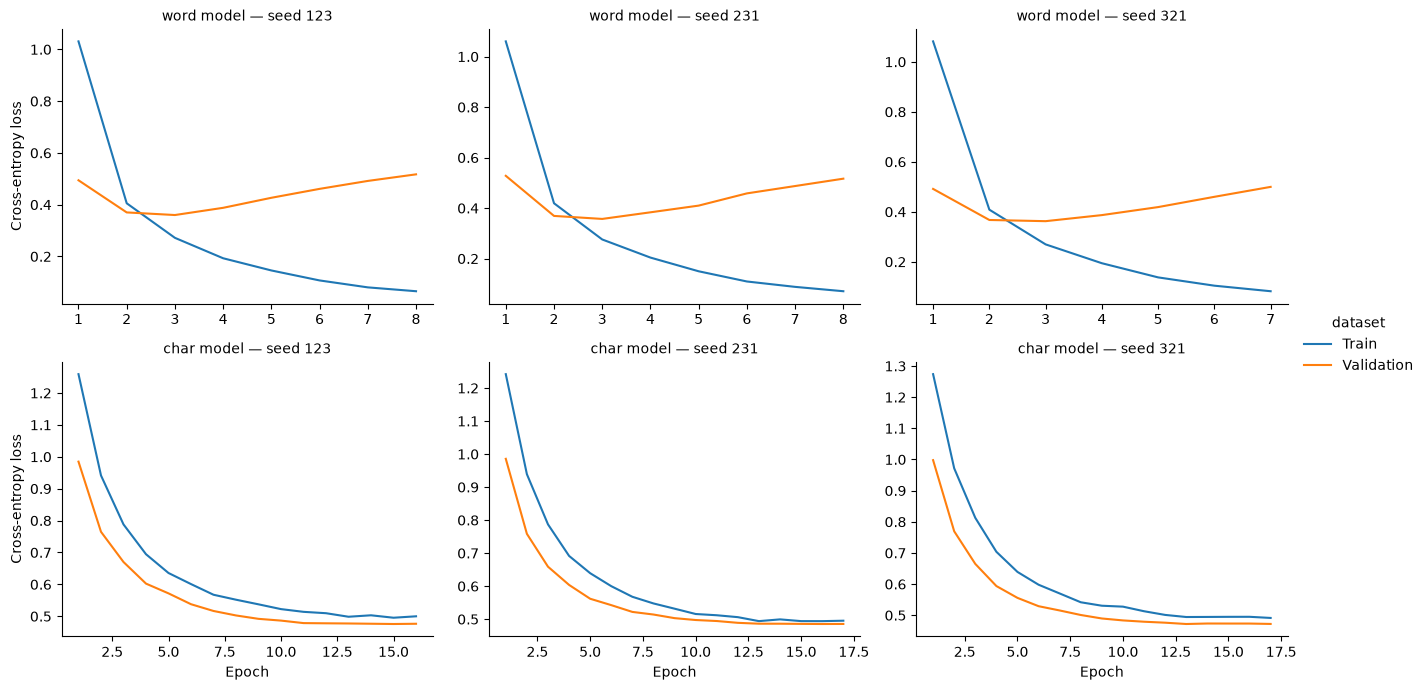

In [35]:
history_frames = []

for model_name in EXPERIMENTS:
    for seed in TRAINING_SEEDS:
        history_df = pd.read_csv(os.path.join(HISTORIES_DIR, f'{model_name}_seed{seed}_{RUN_ID}.csv'))
        history_df['model'] = model_name
        history_df['seed'] = seed
        history_frames.append(history_df)

histories_df = pd.concat(history_frames, ignore_index=True)

loss_df = histories_df.melt(id_vars=['model', 'seed', 'epoch'], value_vars=['loss', 'val_loss'], var_name='dataset', value_name='loss_value')
loss_df['dataset'] = loss_df['dataset'].map({'loss': 'Train', 'val_loss': 'Validation'})

g = sns.relplot(
    data=loss_df,
    x='epoch',
    y='loss_value',
    hue='dataset',
    row='model',
    col='seed',
    kind='line',
    height=3.5,
    aspect=1.25,
    facet_kws={'sharex': False, 'sharey': False},
)
g.set_axis_labels('Epoch', 'Cross-entropy loss')
g.set_titles('{row_name} model — seed {col_name}')

save_figure(g.figure, 'training_dynamics')
plt.show()

In [36]:
metrics_df = pd.DataFrame(metric_rows)
resource_usage_df = pd.DataFrame(resource_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(metrics_df.sort_values(['model', 'seed', 'corruption_level']))

display(
    metrics_df.groupby(['model', 'corruption_level'], as_index=False).agg(
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        f1_macro_mean=('f1_macro', 'mean'),
        f1_macro_std=('f1_macro', 'std'),
        mcc_mean=('mcc', 'mean'),
        mcc_std=('mcc', 'std'),
    )
)

display(resource_usage_df)

,model,seed,corruption_level,n_samples,accuracy,precision_macro,f1_macro,mcc,log_loss
15,char,123,0,2000,0.8055,0.805681,0.804893,0.741115,0.544921
16,char,123,5,2000,0.8050,0.805055,0.804179,0.740535,0.557128
17,char,123,10,2000,0.8040,0.804164,0.803338,0.739142,0.559699
18,char,123,15,2000,0.7950,0.794948,0.794254,0.727124,0.574846
19,char,123,20,2000,0.7915,0.791471,0.790944,0.722345,0.576247
20,char,231,0,2000,0.8135,0.812695,0.812827,0.751497,0.533424
21,char,231,5,2000,0.8115,0.810703,0.810932,0.748769,0.542108
22,char,231,10,2000,0.8015,0.800789,0.800831,0.735525,0.554819
23,char,231,15,2000,0.8025,0.802025,0.801910,0.736887,0.561422
24,char,231,20,2000,0.8025,0.802073,0.802086,0.736794,0.570679


,model,corruption_level,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,mcc_mean,mcc_std
0,char,0,0.809667,0.004010,0.808920,0.003968,0.746572,0.005212
1,char,5,0.806000,0.005074,0.805204,0.005291,0.741658,0.006621
2,char,10,0.803500,0.001803,0.802755,0.001709,0.738349,0.002522
3,char,15,0.799667,0.004072,0.798901,0.004083,0.733242,0.005331
4,char,20,0.797000,0.005500,0.796378,0.005576,0.729620,0.007225
5,word,0,0.853167,0.005508,0.852698,0.005766,0.805112,0.006816
6,word,5,0.849667,0.005485,0.849105,0.006271,0.800677,0.006153
7,word,10,0.842833,0.005686,0.842216,0.006460,0.791651,0.006323
8,word,15,0.836667,0.007006,0.836121,0.007644,0.783839,0.008033
9,word,20,0.823667,0.003253,0.822950,0.004248,0.766976,0.002884


,model,seed,n_parameters,epochs_trained,restored_epoch,training_time_s,training_time_per_epoch_s,initial_ram_mb,peak_ram_mb,ram_increase_mb
0,word,123,189124,8,3,11.046848,1.380856,580.949219,643.074219,62.125000
1,word,231,189124,8,3,11.885566,1.485696,628.710938,655.039062,26.328125
2,word,321,189124,7,2,10.903608,1.557658,637.734375,659.257812,21.523438
3,char,123,30372,16,11,61.620881,3.851305,638.679688,674.574219,35.894531
4,char,231,30372,17,12,67.352211,3.961895,669.097656,686.800781,17.703125
5,char,321,30372,17,12,65.658418,3.862260,662.164062,688.382812,26.218750


# 5. Analysis

## 5.1 Visualization

In [37]:
sns.set_theme(style='whitegrid')


def plot_seed_mean_lines(ax, data, y, *, legend=False, zero_line=False, percentage=False):
    """Plot individual seed trajectories and the across-seed mean for a robustness metric."""
    sns.lineplot(
        data=data,
        x='corruption_level',
        y=y,
        hue='model',
        hue_order=MODEL_ORDER,
        units='seed',
        estimator=None,
        alpha=0.3,
        linewidth=1,
        legend=False,
        ax=ax,
    )
    sns.lineplot(
        data=data,
        x='corruption_level',
        y=y,
        hue='model',
        hue_order=MODEL_ORDER,
        estimator='mean',
        errorbar=None,
        marker='o',
        linewidth=2.5,
        legend=legend,
        ax=ax,
    )

    if zero_line:
        ax.axhline(0, linestyle='--', linewidth=1)
    if percentage:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    ax.set_xlabel('Corruption level (%)')
    ax.set_xticks(CORRUPTION_LEVELS)

In [38]:
analysis_df = metrics_df.melt(id_vars=['model', 'seed', 'corruption_level'], value_vars=list(METRICS), var_name='metric', value_name='performance')

clean_df = (analysis_df.loc[analysis_df['corruption_level'].eq(0), ['model', 'seed', 'metric', 'performance']].rename(columns={'performance': 'clean_performance'}))

analysis_df = analysis_df.merge(clean_df, on=['model', 'seed', 'metric'], how='left')

analysis_df['abs_degradation'] = np.where(analysis_df['metric'].eq('log_loss'), analysis_df['performance'] - analysis_df['clean_performance'], analysis_df['clean_performance'] - analysis_df['performance'])

analysis_df['rel_degradation'] = np.nan

higher_is_better_relative = analysis_df['metric'].isin(['accuracy', 'f1_macro'])
analysis_df.loc[higher_is_better_relative, 'rel_degradation'] = (analysis_df.loc[higher_is_better_relative, 'clean_performance'] - analysis_df.loc[higher_is_better_relative, 'performance']) / analysis_df.loc[higher_is_better_relative, 'clean_performance']

log_loss_mask = analysis_df['metric'].eq('log_loss')
analysis_df.loc[log_loss_mask, 'rel_degradation'] = (analysis_df.loc[log_loss_mask, 'performance'] - analysis_df.loc[log_loss_mask, 'clean_performance']) / analysis_df.loc[log_loss_mask, 'clean_performance']

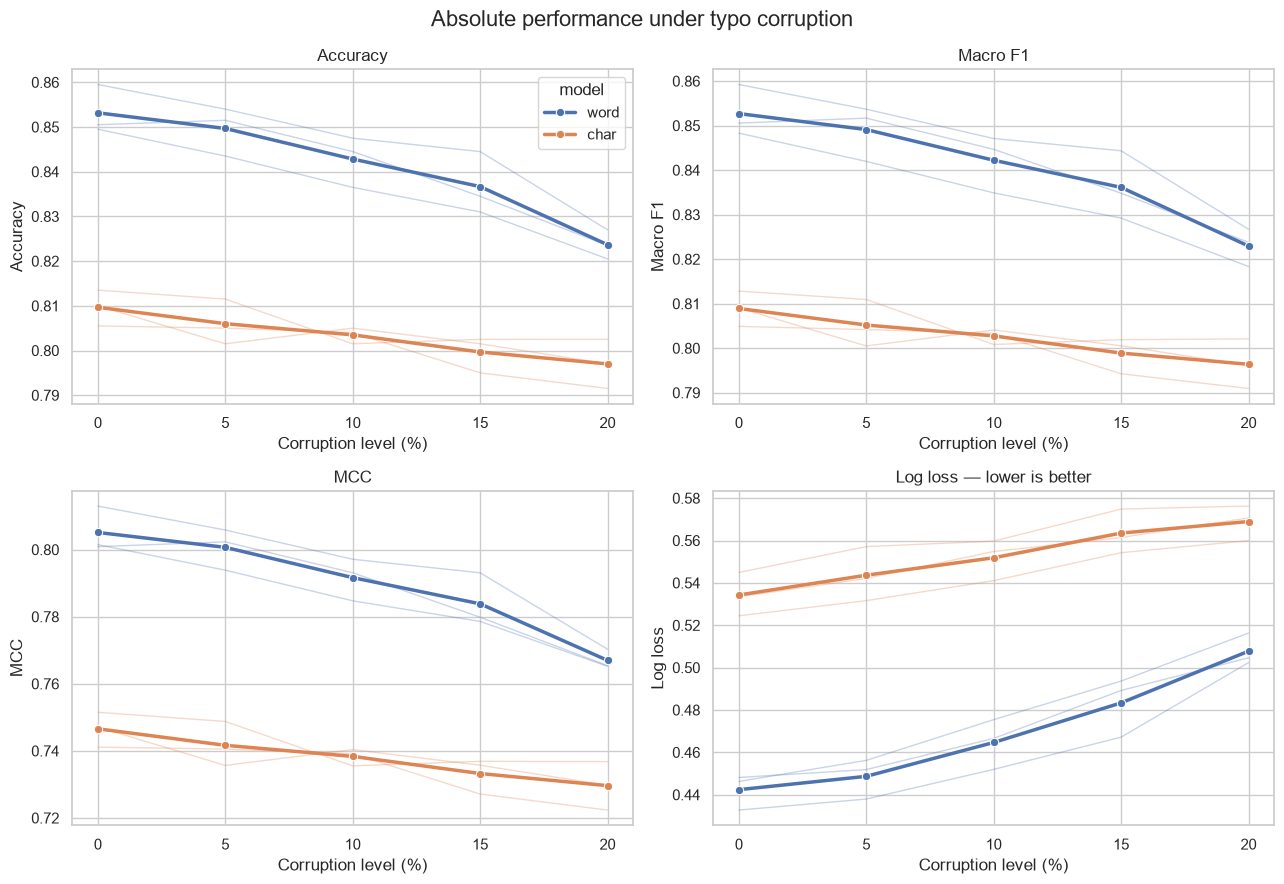

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (metric, label) in zip(axes.flat, METRICS.items()):
    plot_df = analysis_df[analysis_df['metric'].eq(metric)]
    plot_seed_mean_lines(ax, plot_df, 'performance', legend=(metric == 'accuracy'))

    ax.set_title(label)
    ax.set_ylabel(label)

axes[1, 1].set_title('Log loss — lower is better')

fig.suptitle('Absolute performance under typo corruption', fontsize=16)
plt.tight_layout()
save_figure(fig, 'absolute_performance')
plt.show()


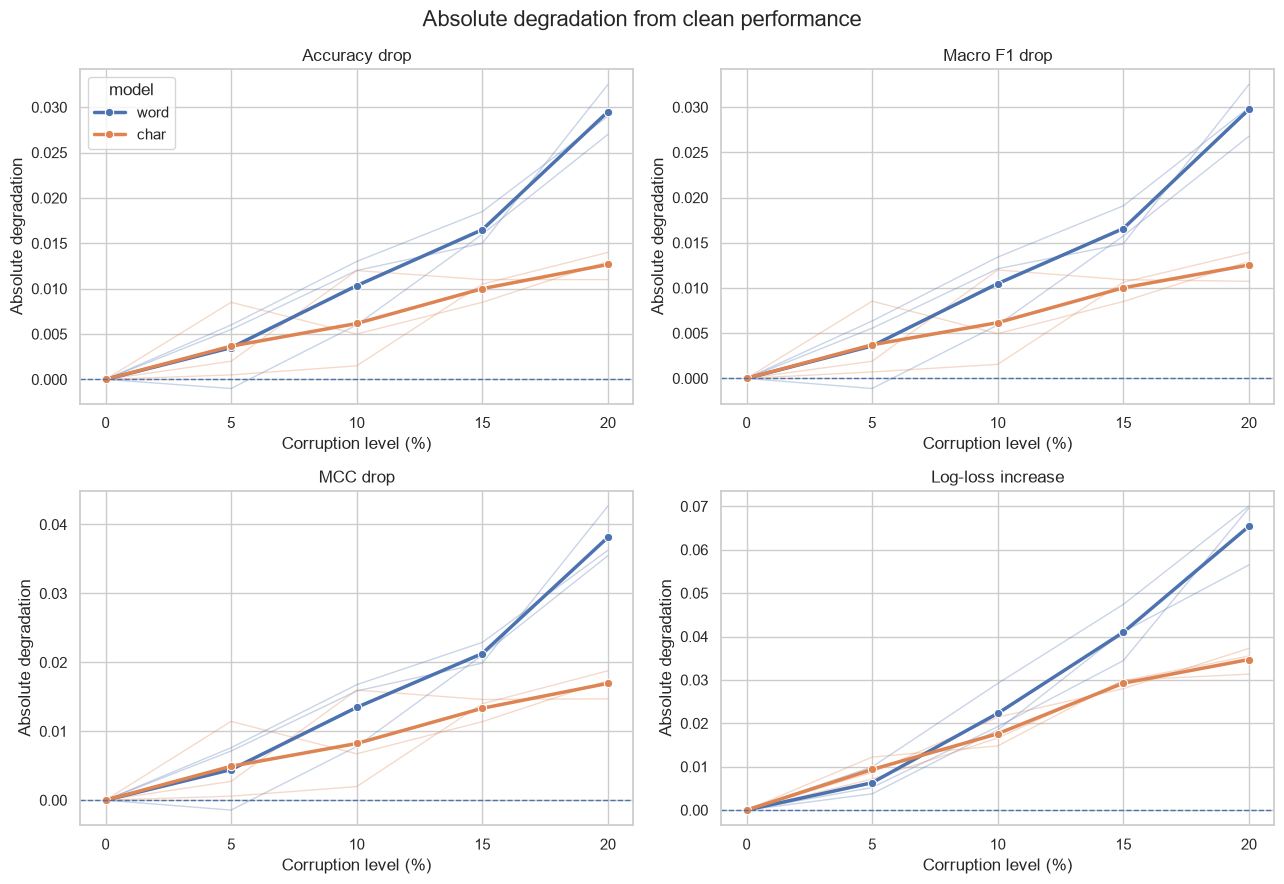

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (metric, label) in zip(axes.flat, ABS_DEGRADATION_LABELS.items()):
    plot_df = analysis_df[analysis_df['metric'].eq(metric)]
    plot_seed_mean_lines(ax, plot_df, 'abs_degradation', legend=(metric == 'accuracy'), zero_line=True)

    ax.set_title(label)
    ax.set_ylabel('Absolute degradation')

fig.suptitle('Absolute degradation from clean performance', fontsize=16)
plt.tight_layout()
save_figure(fig, 'absolute_degradation')
plt.show()

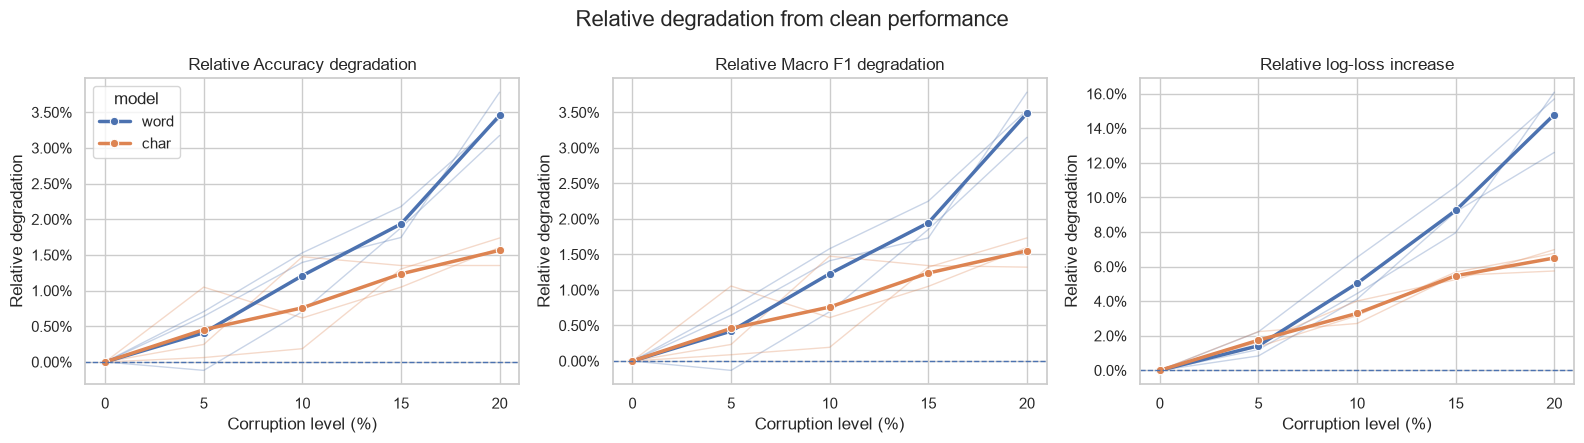

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (metric, label) in zip(axes, RELATIVE_METRICS.items()):
    plot_df = analysis_df[analysis_df['metric'].eq(metric)]
    plot_seed_mean_lines(ax, plot_df, 'rel_degradation', legend=(metric == 'accuracy'), zero_line=True, percentage=True)

    title = 'Relative log-loss increase' if metric == 'log_loss' else f'Relative {label} degradation'
    ax.set_title(title)
    ax.set_ylabel('Relative degradation')

fig.suptitle('Relative degradation from clean performance', fontsize=16)
plt.tight_layout()
save_figure(fig, 'relative_degradation')
plt.show()

In [42]:
mean_f1_degradation_df = (analysis_df.loc[analysis_df['metric'].eq('f1_macro') & analysis_df['corruption_level'].gt(0)].groupby(['model', 'seed'], as_index=False)
    .agg(mean_abs_degradation=('abs_degradation', 'mean'), mean_rel_degradation=('rel_degradation', 'mean')))

In [43]:
f1_degradation_df = analysis_df.loc[analysis_df['metric'].eq('f1_macro'), ['model', 'seed', 'corruption_level', 'abs_degradation', 'rel_degradation']]

word_f1_df = (f1_degradation_df[f1_degradation_df['model'].eq('word')].drop(columns='model').rename(columns={'abs_degradation': 'word_abs_degradation','rel_degradation': 'word_rel_degradation'}))

char_f1_df = (f1_degradation_df[f1_degradation_df['model'].eq('char')].drop(columns='model').rename(columns={'abs_degradation': 'char_abs_degradation', 'rel_degradation': 'char_rel_degradation'}))

f1_delta_df = word_f1_df.merge(char_f1_df, on=['seed', 'corruption_level'])
f1_delta_df['abs_degradation_delta'] = (f1_delta_df['word_abs_degradation'] - f1_delta_df['char_abs_degradation'])
f1_delta_df['rel_degradation_delta'] = (f1_delta_df['word_rel_degradation'] - f1_delta_df['char_rel_degradation'])

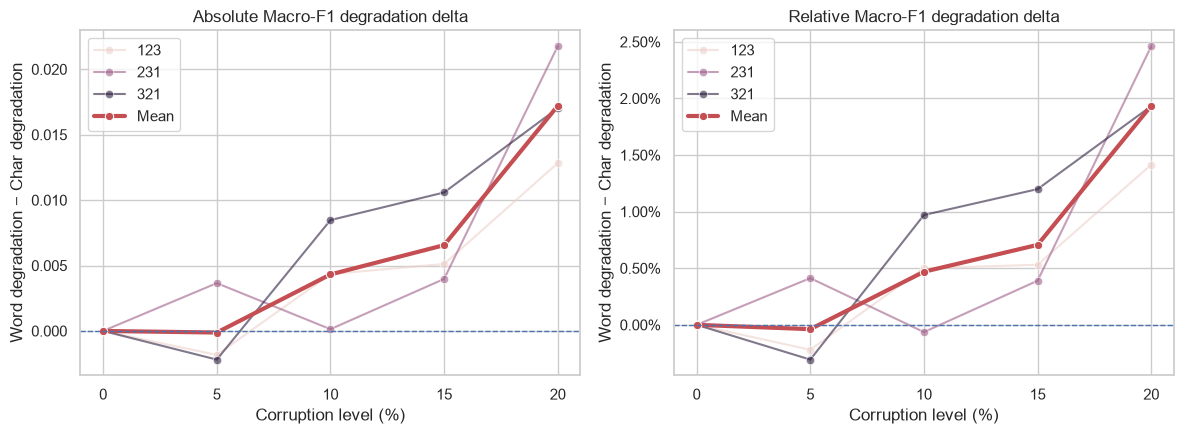

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

delta_plots = [('abs_degradation_delta', 'Absolute Macro-F1 degradation delta', False), ('rel_degradation_delta', 'Relative Macro-F1 degradation delta', True)]

for ax, (y, title, percentage) in zip(axes, delta_plots):
    sns.lineplot(
        data=f1_delta_df,
        x='corruption_level',
        y=y,
        hue='seed',
        units='seed',
        estimator=None,
        marker='o',
        alpha=0.6,
        ax=ax,
    )
    sns.lineplot(
        data=f1_delta_df,
        x='corruption_level',
        y=y,
        estimator='mean',
        errorbar=None,
        marker='o',
        linewidth=3,
        label='Mean',
        ax=ax,
    )

    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Corruption level (%)')
    ax.set_ylabel('Word degradation − Char degradation')
    ax.set_xticks(CORRUPTION_LEVELS)

    if percentage:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
save_figure(fig, 'f1_degradation_delta')
plt.show()

In [45]:
final_result_df = (mean_f1_degradation_df.pivot(index='seed', columns='model', values='mean_abs_degradation').reset_index())

final_result_df['delta_word_minus_char'] = final_result_df['word'] - final_result_df['char']

final_result_df = final_result_df[['seed', 'word', 'char', 'delta_word_minus_char']].rename(columns={'word': 'mean_word_f1_degradation','char': 'mean_char_f1_degradation'})

display(final_result_df.round(4))

model,seed,mean_word_f1_degradation,mean_char_f1_degradation,delta_word_minus_char
0,123,0.0118,0.0067,0.0051
1,231,0.0163,0.0089,0.0074
2,321,0.0172,0.0087,0.0085


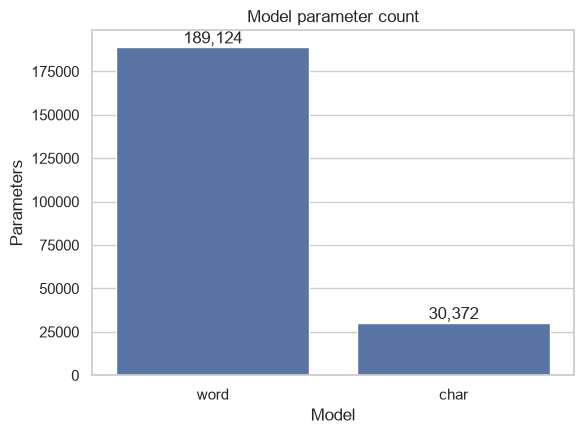

In [46]:
parameter_df = (resource_usage_df.groupby('model', as_index=False).agg(n_parameters=('n_parameters', 'first')))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(data=parameter_df, x='model', y='n_parameters', order=MODEL_ORDER, ax=ax)

parameter_labels = (parameter_df.set_index('model').loc[MODEL_ORDER, 'n_parameters'].map(lambda value: f'{value:,.0f}'))
ax.bar_label(ax.containers[0], labels=parameter_labels)

ax.set_title('Model parameter count')
ax.set_xlabel('Model')
ax.set_ylabel('Parameters')

plt.tight_layout()
save_figure(fig, 'parameter_count')
plt.show()

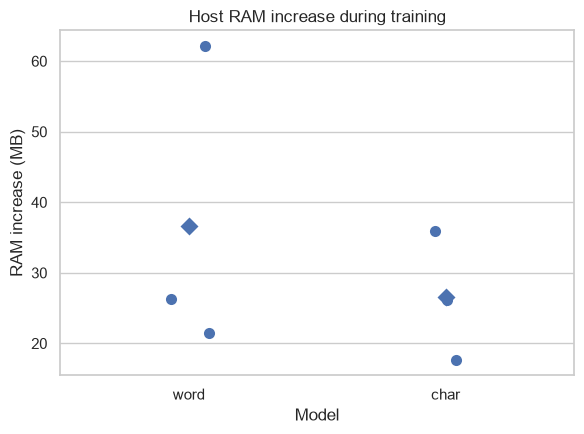

In [47]:
fig, ax = plt.subplots(figsize=(6, 4.5))

sns.stripplot(
    data=resource_usage_df,
    x='model',
    y='ram_increase_mb',
    order=MODEL_ORDER,
    jitter=0.08,
    size=8,
    ax=ax,
)
sns.pointplot(
    data=resource_usage_df,
    x='model',
    y='ram_increase_mb',
    order=MODEL_ORDER,
    estimator='mean',
    errorbar=None,
    linestyle='none',
    marker='D',
    markersize=7,
    # capsize=0.15,
    ax=ax,
)

ax.set_title('Host RAM increase during training')
ax.set_xlabel('Model')
ax.set_ylabel('RAM increase (MB)')

plt.tight_layout()
save_figure(fig, 'ram_increase')
plt.show()

## 5.2 Statistics

In [48]:
mcnemar_rows = []

for seed in TRAINING_SEEDS:
    for corruption_level in CORRUPTION_LEVELS:

        paired_df = (predictions_df[(predictions_df['seed'] == seed) & (predictions_df['corruption_level'] == corruption_level)].pivot(index='sample_id', columns='model', values='correct',))

        word_correct = paired_df['word'].astype(bool)
        char_correct = paired_df['char'].astype(bool)

        both_correct = (word_correct & char_correct).sum()
        word_only_correct = (word_correct & ~char_correct).sum()
        char_only_correct = (~word_correct & char_correct).sum()
        both_wrong = (~word_correct & ~char_correct).sum()

        table = [[both_correct, word_only_correct], [char_only_correct, both_wrong]]

        result = mcnemar(table, exact=True)

        mcnemar_rows.append({
            'seed': seed,
            'corruption_level': corruption_level,
            'n_samples': len(paired_df),
            'both_correct': both_correct,
            'word_only_correct': word_only_correct,
            'char_only_correct': char_only_correct,
            'both_wrong': both_wrong,
            'accuracy_delta_word_minus_char': (word_only_correct - char_only_correct) / len(paired_df),
            'p_raw': result.pvalue,
        })

mcnemar_df = pd.DataFrame(mcnemar_rows)

reject, p_holm, _, _ = multipletests(mcnemar_df['p_raw'], alpha=0.05, method='holm')

mcnemar_df['p_holm'] = p_holm
mcnemar_df['significant_holm_0.05'] = reject

mcnemar_df.to_csv(os.path.join(RESULTS_DIR, f'mcnemar_holm_{RUN_ID}.csv'), index=False)

display(mcnemar_df)

,seed,corruption_level,n_samples,both_correct,word_only_correct,char_only_correct,both_wrong,accuracy_delta_word_minus_char,p_raw,p_holm,significant_holm_0.05
0,123,0,2000,1509,192,102,197,0.0450,1.694378e-07,2.033253e-06,True
1,123,5,2000,1508,195,102,195,0.0465,7.404368e-08,1.036612e-06,True
2,123,10,2000,1496,193,112,199,0.0405,4.096171e-06,2.867320e-05,True
3,123,15,2000,1467,202,123,208,0.0395,1.381750e-05,8.290497e-05,True
4,123,20,2000,1441,206,142,211,0.0320,7.100480e-04,2.840192e-03,True
5,231,0,2000,1534,185,93,188,0.0460,3.653233e-08,5.479849e-07,True
6,231,5,2000,1519,189,104,188,0.0425,7.790376e-07,8.569414e-06,True
7,231,10,2000,1497,198,106,199,0.0460,1.456119e-07,1.892954e-06,True
8,231,15,2000,1497,192,108,203,0.0420,1.420658e-06,1.278592e-05,True
9,231,20,2000,1470,184,135,211,0.0245,7.104894e-03,1.420979e-02,True
